# Tutorial 6 - Simple Linear Regression

A hospital's central sterile processing tracks the electrical energy used each month to run sterilizers, washers, ventilation, and supporting equipment. The hospital is interested in better understanding and being able to predict energy use. You suspect monthly electricity use is related to operational and quality factors:

* y = monthly electrical energy used (e.g., in MWh)
* x1 = average ambient temperature in the facility area that month (°C)
* x2 = number of operating days in the month (days)
* x3 = average sterilization quality score for that month (%, higher is better)
* x4 = number of instrument trays processed that month (in hundreds of trays)

The past year's historical data are provided in the EnergyUse.csv file.

# Part 1: Read in the Data and EDA

In [1]:
%reset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [2]:
energy=pd.read_csv('EnergyUse.csv')
energy

,EnergyUse,Temp,NoDays,QAScore,TrayNumber
0,240,25,24,91,100
1,236,31,21,90,95
2,270,45,24,88,110
3,274,60,25,87,88
4,301,65,25,91,94
5,316,72,26,94,99
6,300,80,25,87,97
7,296,84,25,86,96
8,267,75,24,88,110
9,276,60,25,91,105


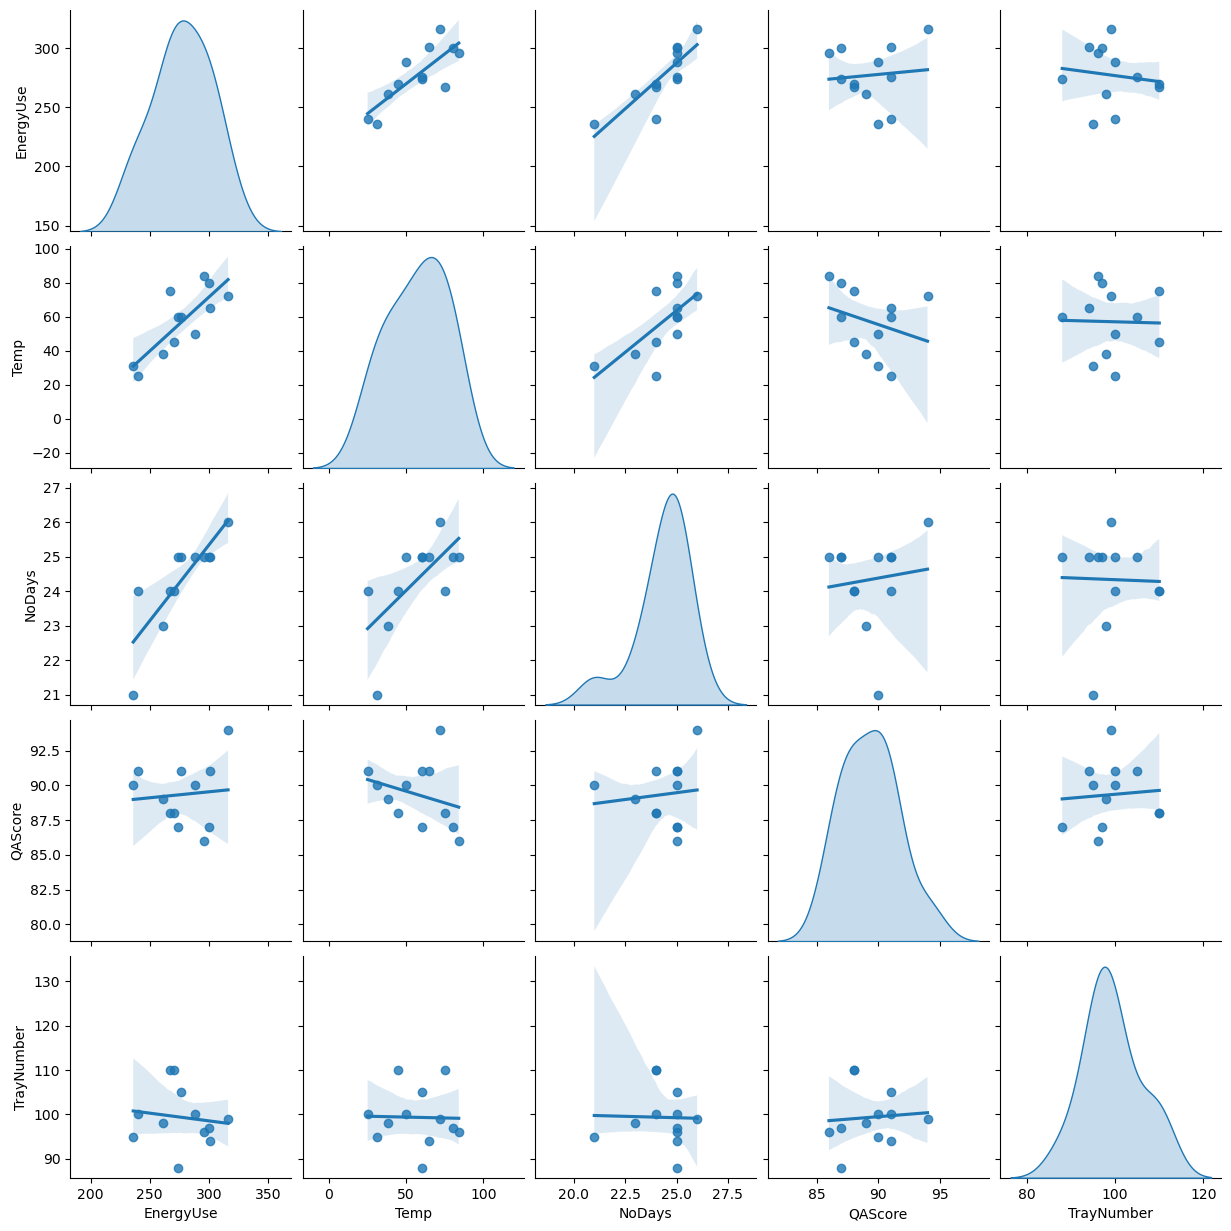

In [3]:
sns.pairplot(data=energy,kind='reg',diag_kind='kde')

In [4]:
energy.describe()

,EnergyUse,Temp,NoDays,QAScore,TrayNumber
count,12.000000,12.000000,12.000000,12.000000,12.000000
mean,277.083333,57.083333,24.333333,89.333333,99.333333
std,24.444588,19.406926,1.302678,2.269695,6.429101
min,236.000000,25.000000,21.000000,86.000000,88.000000
25%,265.500000,43.250000,24.000000,87.750000,95.750000
50%,275.000000,60.000000,25.000000,89.500000,98.500000
75%,297.000000,72.750000,25.000000,91.000000,101.250000
max,316.000000,84.000000,26.000000,94.000000,110.000000


In [5]:
energy.cov()

,EnergyUse,Temp,NoDays,QAScore,TrayNumber
EnergyUse,597.537879,380.719697,26.333333,5.151515,-20.848485
Temp,380.719697,376.628788,16.696970,-12.666667,-2.939394
NoDays,26.333333,16.696970,1.696970,0.333333,-0.212121
QAScore,5.151515,-12.666667,0.333333,5.151515,1.151515
TrayNumber,-20.848485,-2.939394,-0.212121,1.151515,41.333333


In [6]:
cov_energy_nodays = np.cov(energy["EnergyUse"], energy["NoDays"], ddof=1)[0,1]
var_nodays = np.var(energy["NoDays"], ddof=1)
print("Cov(EnergyUse, NoDays):", cov_energy_nodays)
print("Var(NoDays):", var_nodays)

Cov(EnergyUse, NoDays): 26.333333333333336
Var(NoDays): 1.6969696969696975


In [7]:
energy.corr()

,EnergyUse,Temp,NoDays,QAScore,TrayNumber
EnergyUse,1.000000,0.802538,0.826963,0.092851,-0.132660
Temp,0.802538,1.000000,0.660456,-0.287566,-0.023559
NoDays,0.826963,0.660456,1.000000,0.112739,-0.025328
QAScore,0.092851,-0.287566,0.112739,1.000000,0.078914
TrayNumber,-0.132660,-0.023559,-0.025328,0.078914,1.000000


### **QUESTION 1**

(a) What appears to have the highest linear association by the bivariant plot?

(b) How do you summarize this linear association?

(c) Identify the response variable and a best candidate predictor variable for a simple linear regression model to address your research question.

**ANSWER:**

a)Based on the correlation by bivariant plot, the variable that appears to have the highest lonear association is NoDays 

b)To summerize this linear association between EnergyUse and NoDays is that it is strong and positive

c)The response variable y will be EnergyUse and the best candidate predictor variable for a simple linear regression model would be NoDays

# Part 2: Fit the SLR in Python and using the closed-form OLS solution.

In [8]:
from statsmodels.formula.api import ols

model1=ols('EnergyUse~NoDays',data=energy)
results1=model1.fit()
print(results1.summary2())

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.652   
Dependent Variable: EnergyUse        AIC:                99.9051 
Date:               2026-03-06 11:55 BIC:                100.8749
No. Observations:   12               Log-Likelihood:     -47.953 
Df Model:           1                F-statistic:        21.63   
Df Residuals:       10               Prob (F-statistic): 0.000907
R-squared:          0.684            Scale:              207.79  
-----------------------------------------------------------------
                Coef.   Std.Err.    t    P>|t|    [0.025   0.975]
-----------------------------------------------------------------
Intercept     -100.5179  81.2927 -1.2365 0.2445 -281.6492 80.6135
NoDays          15.5179   3.3364  4.6511 0.0009    8.0839 22.9519
-----------------------------------------------------------------
Omnibus:               4.560        Durbin-Watson:          1.555
Prob(Omnibus):         0.10

### Closed-Form Solution to OLS Regression

We can find the coefficients that fit this model through the solutions to the closed form solution of minimizing the sum of the squared error terms. 

Fit the simple linear regression model

$y = \beta_0 + \beta_1 x_1 + \epsilon$

We will do this through using the normal equations that are found using calculus (minimizing the squares of the residuals by partial differentiation and setting these equal to 0).  There will be one more than the number of predictors; one for each of the unknown regression coefficients.  The solution to the normal equations will be the estimators of the regression coefficients beta, beta1.  

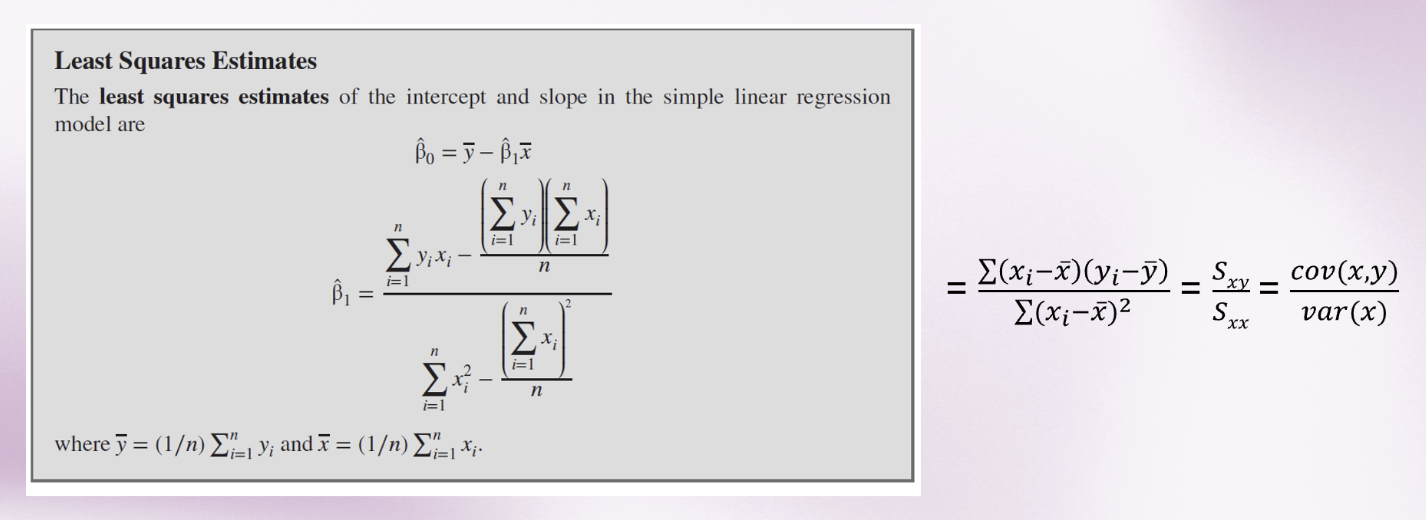

### **TASK 1: Compute the Closed-Form OLS Estimates**

Using the formulas above (and below), compute $\hat{\beta}_1$ and $\hat{\beta}_0$:

$$\hat{\beta}_1 = \frac{cov(x, y)}{var(x)} \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

In [11]:
# YOUR CODE HERE — compute beta1
beta1 = energy['EnergyUse'].cov(energy['NoDays']) / energy['NoDays'].var()
print(beta1)

15.51785714285714


In [12]:
# YOUR CODE HERE — compute beta0
beta0 = energy['EnergyUse'].mean() - beta1 * energy['NoDays'].mean()
print(beta0)

-100.51785714285711


Verify that your values match the Python model:

In [9]:
results1.params

Intercept   -100.517857
NoDays        15.517857
dtype: float64

### **QUESTION 2**

(a) Interpret the slope and intercept of the fitted model in context.

(b) Write the fitted model.

**ANSWER:**

a)The slope is B1 which is 15.517857, so for every additional operating day in a month, the monthly electrical energy used increases by 15.517857. The intercept is B0 which is -100.517857, so for zero operating days, there monthly electrical used is -100.517857 (which is far from our operating days)

b)y = 15.5179*x2 -100.5179

# Part 3: Test for the Effect of the Number of Days on EnergyUse

### Key Equations for Testing and Inference

Estimator of Variance (MSE):

$$\hat{\sigma}^2 = \frac{SS_E}{n - 2}$$

Test Statistic for the Slope:

$$T_0 = \frac{\hat{\beta}_1 - \beta_{1,0}}{\sqrt{\hat{\sigma}^2 / S_{xx}}}$$

Hypotheses:

$$H_0: \beta_1 = 0 \qquad H_1: \beta_1 \neq 0$$

95% Confidence Interval for the Slope:

$$\hat{\beta}_1 - t_{\alpha/2,\, n-2} \sqrt{\frac{\hat{\sigma}^2}{S_{xx}}} \;\leq\; \beta_1 \;\leq\; \hat{\beta}_1 + t_{\alpha/2,\, n-2} \sqrt{\frac{\hat{\sigma}^2}{S_{xx}}}$$

In [13]:
from statsmodels.stats.anova import anova_lm
anova_results1 = anova_lm(results1)
print(anova_results1)

            df       sum_sq      mean_sq          F    PR(>F)
NoDays     1.0  4495.005952  4495.005952  21.632334  0.000907
Residual  10.0  2077.910714   207.791071        NaN       NaN


In [14]:
# attributes of object results1:  e.g.:  ssr is SS Residuals; sse is SS Estimate/Regression
print("SS Residuals:", results1.ssr)

SS Residuals: 2077.9107142857138


In [15]:
# SSE
SSE = np.sum((energy["EnergyUse"] - results1.fittedvalues)**2)
print("SSE (by hand):", SSE)
print("SSE (verification):", np.sum(np.square(results1.resid)))

SSE (by hand): 2077.9107142857138
SSE (verification): 2077.9107142857138


In [16]:
# MSE
MSE=SSE/(len(energy["NoDays"])-2)
print("MSE (by hand):", MSE)
print("MSE (from results1):", results1.mse_resid)

MSE (by hand): 207.79107142857137
MSE (from results1): 207.79107142857137


In [17]:
# R-square
R_square=results1.ess/results1.centered_tss
print("R-squared:", R_square)
# for slr r^square is equal to R-square
print("r^2 verification:", np.square(np.corrcoef(energy["EnergyUse"],energy["NoDays"]) [0,1]))

R-squared: 0.6838677835635046
r^2 verification: 0.6838677835635047


### **TASK 2: Standard Error of the Slope and 95% Confidence Interval**

The standard error of the slope tells us how precisely we have estimated $\hat{\beta}_1$. It is calculated as:

$$se(\hat{\beta}_1) = \sqrt{\frac{MSE}{(n-1) \cdot var(x)}}$$

The 95% confidence interval for the slope is then:

$$\hat{\beta}_1 \pm t_{\alpha/2,\, n-2} \cdot se(\hat{\beta}_1)$$

In [18]:
import scipy.stats as stats

In [20]:
# YOUR CODE HERE — compute se_beta1 using the formula above
n = len(energy)
se_beta1 = np.sqrt(MSE / ((n - 1) * energy["NoDays"].var()))

In [21]:
# t-statistic
t_stat=beta1/se_beta1
print("t-statistic:", t_stat)

t-statistic: 4.6510573472773205


In [22]:
# p-value of t-statistic
p_value = 2*(1-(stats.t.cdf(abs(t_stat),len(energy["NoDays"])-2)))
print("p-value:", p_value)

p-value: 0.0009065809533888025


In [23]:
t_crit=stats.t.ppf(0.975,len(energy["NoDays"])-2)
print("t-critical:", t_crit)

t-critical: 2.2281388519649385


In [25]:
# YOUR CODE HERE — compute the 95% CI of the slope (UL and LL) using the formula above
lower_limit = beta1 - (t_crit * se_beta1)
upper_limit = beta1 + (t_crit * se_beta1)
print(lower_limit, upper_limit)

8.083861425844102 22.95185285987018


### **QUESTION 3**

Based on the outputs above:

(a) Interpret what MSE and R² tell you about this model.

(b) Based on the t-statistic, p-value, and confidence interval, is NoDays a statistically significant predictor of EnergyUse? Explain your reasoning.

**ANSWER:**

a)MSE represents the mean squared deviation which is 207.79. This is a unexplained variance in Energy Use that is not in NoDays. R^2 represents the total variation used in EnergyUsed by NoDays which is 68.4%.

b)Based on the t-statistics, p, and confidence interval NoDays is a statistically significant predictor of EnergyUse. P-value (0.0009 < 0.05), which reject null hypothesis and suggets that there that there is a relationship between NoDays and EnergyUse is not from random chance. T-stat (4.65 > 2.228) the calculated t-stat is greater than the t-critical which means that it is statistically far from 0, which is proven also from the confidence interval that it does not include 0.

# Part 4: Review the Assumptions for Linear Regression

### Diagnostic Plots

Run the cells below and use the outputs to answer Question 4.

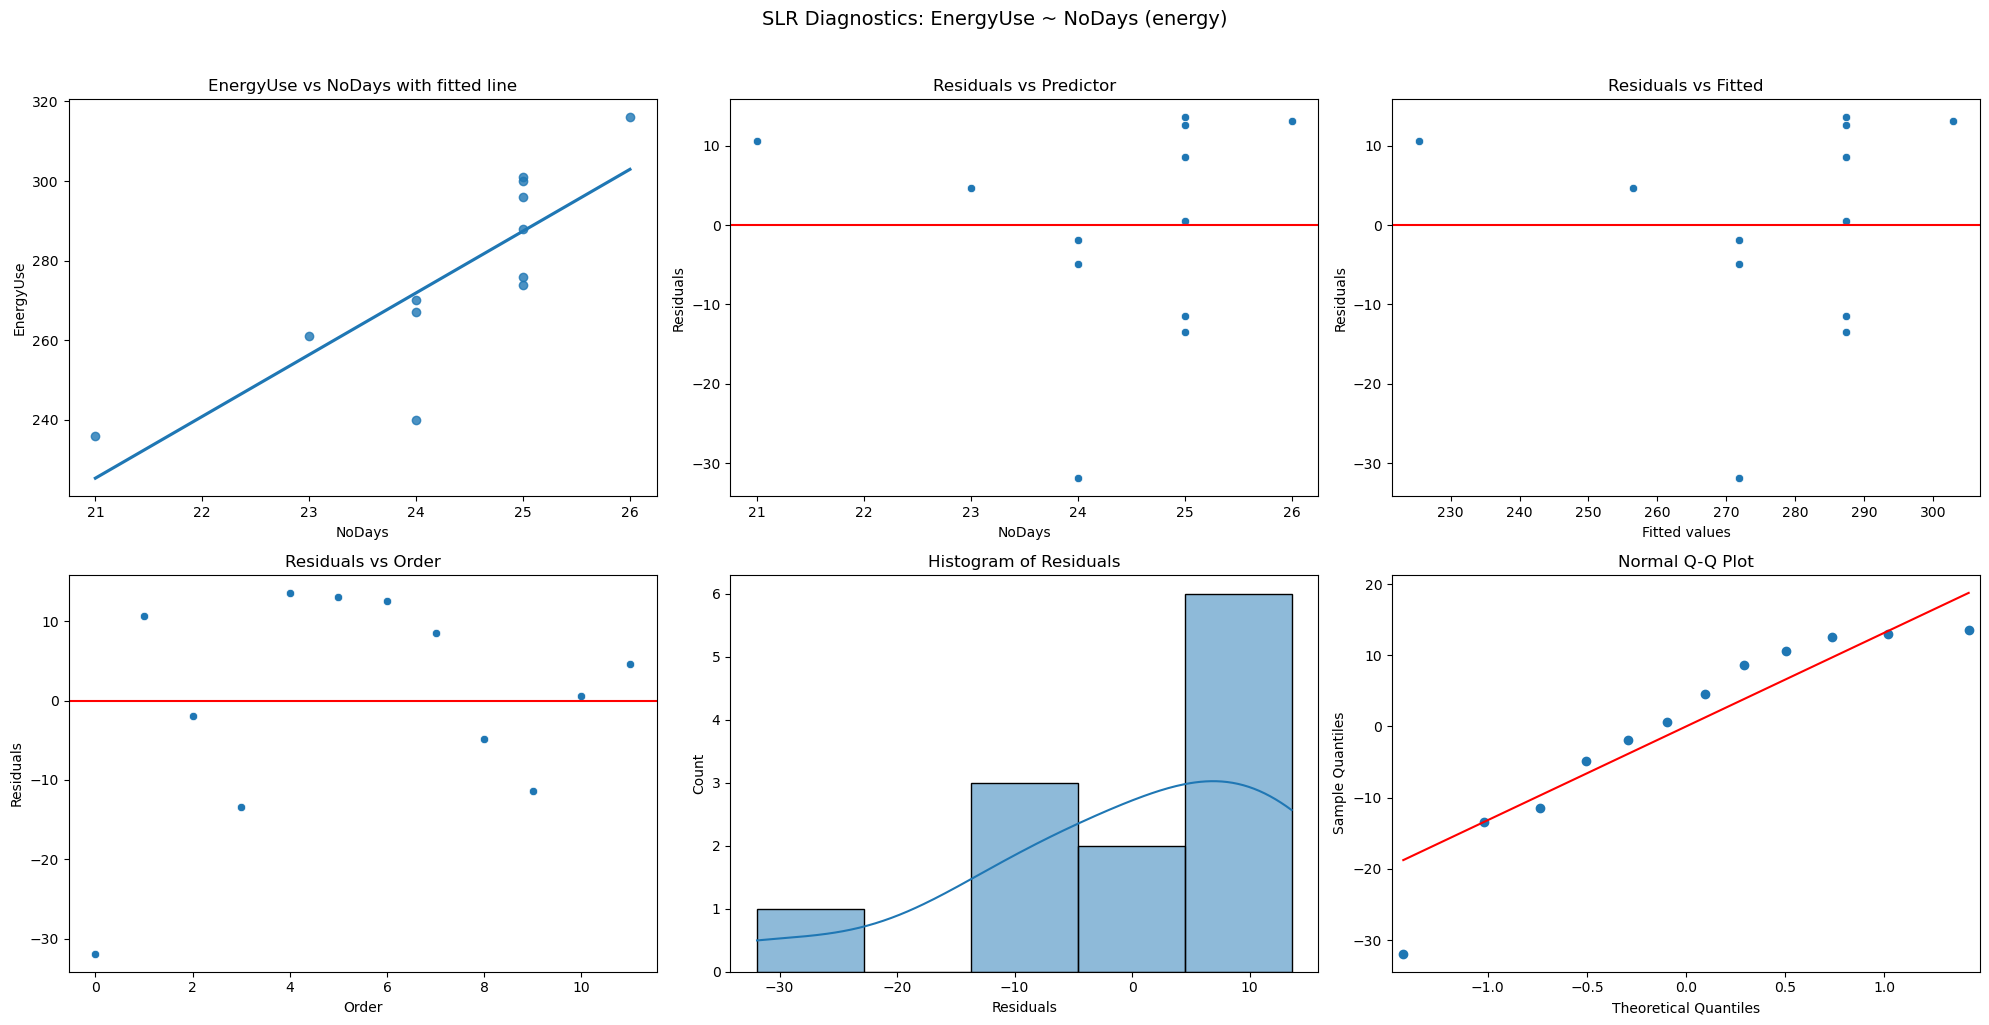

In [26]:
# NIST 6 plots for SLR

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

def slr_diagnostic_grid(df, x_col, y_col, results, df_name="df"):
    
    residuals = results.resid
    fitted = results.fittedvalues

    fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

    # 1) Scatter + fitted line (original scale)
    sns.regplot(x=df[x_col], y=df[y_col], ci=None, ax=ax[0, 0])
    ax[0, 0].set_title(f"{y_col} vs {x_col} with fitted line")

    # 2) Residuals vs X
    sns.scatterplot(x=df[x_col], y=residuals, ax=ax[0, 1])
    ax[0, 1].axhline(0, color="red")
    ax[0, 1].set_xlabel(x_col)
    ax[0, 1].set_ylabel("Residuals")
    ax[0, 1].set_title("Residuals vs Predictor")

    # 3) Residuals vs Fitted
    sns.scatterplot(x=fitted, y=residuals, ax=ax[0, 2])
    ax[0, 2].axhline(0, color="red")
    ax[0, 2].set_xlabel("Fitted values")
    ax[0, 2].set_ylabel("Residuals")
    ax[0, 2].set_title("Residuals vs Fitted")

    # 4) Residuals vs Order
    sns.scatterplot(x=np.arange(len(df)), y=residuals, ax=ax[1, 0])
    ax[1, 0].axhline(0, color="red")
    ax[1, 0].set_xlabel("Order")
    ax[1, 0].set_ylabel("Residuals")
    ax[1, 0].set_title("Residuals vs Order")

    # 5) Histogram of residuals
    sns.histplot(x=residuals, stat="count", kde=True, ax=ax[1, 1])
    ax[1, 1].set_xlabel("Residuals")
    ax[1, 1].set_title("Histogram of Residuals")

    # 6) Q-Q plot
    sm.qqplot(residuals, line="s", ax=ax[1, 2])
    ax[1, 2].set_title("Normal Q-Q Plot")

    fig.suptitle(f"SLR Diagnostics: {y_col} ~ {x_col} ({df_name})", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

# Add the df and variables below
x_col = "NoDays"
y_col = "EnergyUse"
X = sm.add_constant(energy[x_col])
results1 = sm.OLS(energy[y_col], X).fit()
slr_diagnostic_grid(energy, x_col, y_col, results1, df_name="energy")

### Additional Assumption Plots and Tests

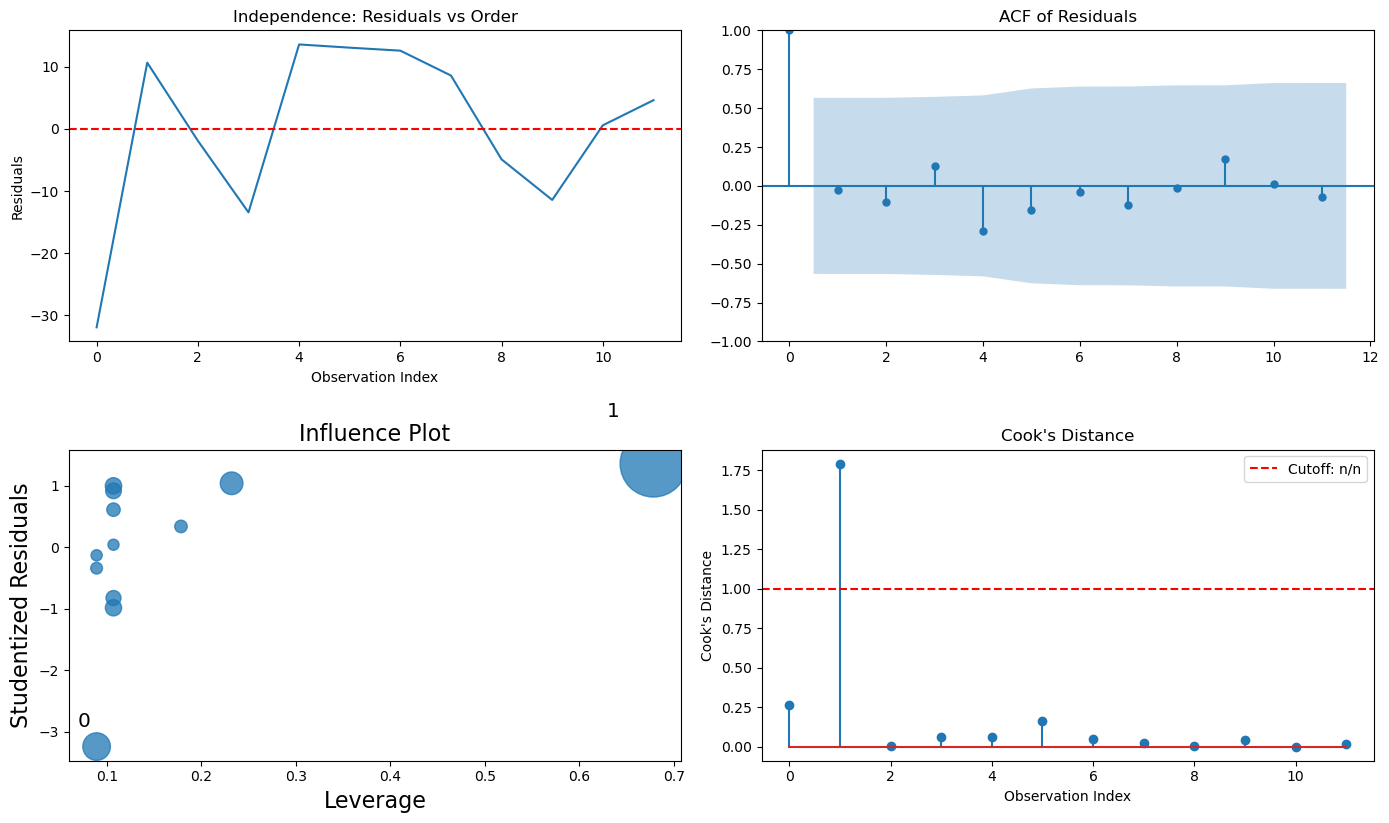


Statistical Tests:
Durbin-Watson: 1.555 (test for independence of residuals; ideal ≈ 2)
Shapiro-Wilk p-value: 0.1033 (p > 0.05 → normality)


In [27]:
#  Other Assumption Plots and Tests

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.regressionplots import influence_plot
from statsmodels.graphics.tsaplots import plot_acf  
from scipy.stats import shapiro

# --- Fit final model ---
final_model = results1

# --- Residuals and Fitted Values ---
residuals = final_model.resid
fitted = final_model.fittedvalues

# --- Diagnostic Plots ---
plt.figure(figsize=(14, 12))

# Independence (residuals in order)
plt.subplot(3, 2, 1)
sns.lineplot(x=np.arange(len(residuals)), y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Independence: Residuals vs Order')
plt.xlabel('Observation Index')
plt.ylabel('Residuals')

# ACF of residuals for independence
plt.subplot(3, 2, 2)
plot_acf(residuals, ax=plt.gca(), lags=len(final_model.resid)-1)
plt.title('ACF of Residuals')

# Influence Plot
plt.subplot(3, 2, 3)
influence_plot(final_model, ax=plt.gca(), criterion="cooks")

# Cook's Distance
plt.subplot(3, 2, 4)
influence = final_model.get_influence()
cooks = influence.cooks_distance[0]

plt.stem(np.arange(len(cooks)), cooks)
plt.axhline(len(residuals)/len(residuals), color='red', linestyle='--', label='Cutoff: n/n')
plt.title("Cook's Distance")
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")
plt.legend()

plt.tight_layout()
plt.show()

# --- Statistical Tests ---
print("\nStatistical Tests:")
print(f"Durbin-Watson: {durbin_watson(residuals):.3f} (test for independence of residuals; ideal ≈ 2)")
print(f"Shapiro-Wilk p-value: {shapiro(residuals).pvalue:.4f} (p > 0.05 → normality)")

### **QUESTION 4**

Based on the diagnostic plots above, assess each assumption:

(a) Linearity
  - Does the relationship between NoDays and EnergyUse appear approximately linear?
  - Is there evidence of curvature in the residual plot?

(b) Independence
  - Based on the residuals vs order plot, do the residuals appear independent?

(c) Equal Variance (Homoscedasticity)
  - Does the spread of residuals appear roughly constant?
  - Is there evidence of a funnel shape?

(d) Normality of Errors
  - Based on the histogram and Q-Q plot, do the residuals appear approximately normally distributed?
  - Are there substantial deviations in the tails?

(e) Overall, are the regression assumptions reasonably satisfied? Are there any concerns?

**ANSWER:**

a)The relationship between NoDays and EnergyUse appear approximately linear in the scatter plot and in the residual plot, there is no evidence of curvature.

b)Based on the residuals vs order plot, the residual does appear independent as the values appear either above or below the red line. 

c)The spread of the residuals appear non-constant and is evidence of a somewhat funnel shape (it is slightly hard to tell). The model is much more accurate at one end of the data range  and becomes increasingly inaccurate at the other end,

d)Yes, as Q-Q plot follows a linear regression model but it does have deviation as it is a right tail from the histogram plot.

e) the overall regression assumption from all of the things stated above is that the assumption of normality is satistifed. There is slight concern from the histogram model, though the Q-Q plot shows that it falls a diagnal line. 

# Part 5: Prediction Model with Train/Test Split

### Taking it from *Stats* to Prediction

In Parts 1 through 4, we used SLR for statistical inference, asking "is there a significant relationship between NoDays and EnergyUse?" and testing that with hypothesis tests, confidence intervals, and assumption checks. This is the classical statistics side: understanding why things are related.

But there's another question: can this model actually predict well on new data it hasn't seen before? This is the prediction side, and it's where SLR connects to the broader world of AI and predictive modeling.

The concern is overfitting. A model might fit the training data perfectly but fail on new data because it learned the noise rather than the real pattern. To check this, we split our data:

- Training set: the model learns from this data (fits the line)
- Test set: held-back data used to evaluate how well the model predicts on unseen observations

If the model performs similarly on both sets, it generalizes well. If it performs much better on training than testing, it's overfitting.

We use sklearn (Scikit-learn) here, a Python toolkit used for predictive modeling (machine learning), whereas statsmodels (Parts 1 through 3) is for classical statistical inference (p-values, confidence intervals).

We split the data (n=12) into 75% training (9 points) and 25% testing (3 points), with random_state=2026 for reproducibility.

### Signs of Overfitting vs. Underfitting

Overfitting (model too complex / learned noise):
- RMSE: train ≪ test (e.g. train 0.5, test 2.1)
- R²: train ≫ test (e.g. train 0.98, test 0.55)

Underfitting (model too simple / wrong form):
- RMSE: both big (e.g. train 18.5, test 18.7)
- R²: both small (e.g. train 0.25, test 0.20)
- Interpretation: linear model not capturing the relationship. Relative to scale of y.

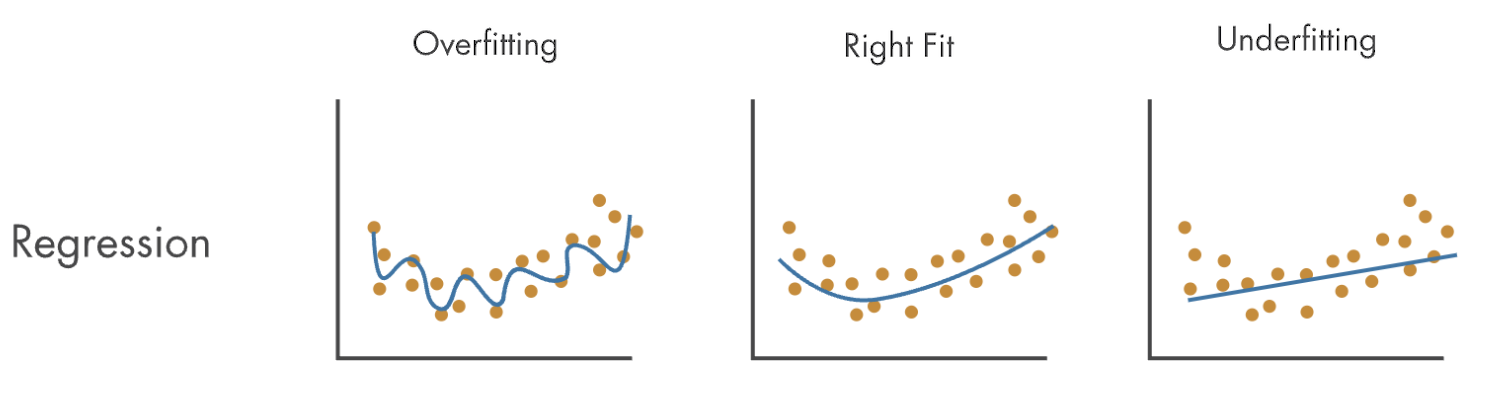

In [29]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = energy[["NoDays"]]
y = energy["EnergyUse"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=2026
)

In [30]:
# Fit the training mode and then apply to the testing data
# Calcuate the data (think of the data as the population, so no dof adjustments) MSE and R-squared to view how well the data can be generalized to unseen data

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred_test))

Train RMSE: 15.091073091811761
Test RMSE: 3.281734556241449
Train R²: 0.6655368703619899
Test R²: 0.9145255420823075


### **QUESTION 5**

(a) Is test performance similar to train performance?

(b) What does it mean if test performance is much worse?

(c) What do you conclude about the generalizability of the model?

**ANSWER:**

a)The performance is not similar to train performance as the train performance is 15 whereas the test performance 3. Therefore the train performance is greater than test performance.

b)What it means if test performance is much worse than the model memorizes training data rather than generalizing to new data.

c)The generalizability is questionable due to the tiny sample size used (12 N). To have a good generalizability, a large data set is needed to make assumptions.

---

# Submission Instructions

**Due Date:** Friday, March 6, 2026

**How to Submit:**
1. Make sure all code cells have been run and show outputs
2. Make sure all TASK cells are completed with your code
3. Make sure all QUESTION cells are filled in with your answers
4. Save your notebook as: `Tutorial6_YourName.ipynb` (replace "YourName" with your actual name)
5. Export as PDF (File → Save and Export Notebook As → PDF)
6. Submit both the .ipynb and PDF to the Tutorial 6 dropbox on Avenue to Learn

**Need Help?**
- Jala and Imran will be available during office hours **Wednesday** and **Thursday**
- Check Avenue to Learn for office hours times and locations
- You can also post questions on the course discussion board